# TS5:Estimación espectral: Ancho de banda de señales reales

### Angel Joseph Vargas Martinez
## Introducción

La densidad espectral de potencia (PSD) es una herramienta utilizada para analizar cómo se distribuye la potencia o energía de una señal en frecuencia. Matemáticamente, la PSD puede obtenerse como la Transformada de Fourier de Tiempo Discreto (DTFT) de la función de autocorrelación de la señal, permitiendo identificar las componentes frecuenciales dominantes y estimar el ancho de banda de una señal.

Sin embargo, al trabajar con señales reales aparecen dos limitaciones importantes. En primer lugar, no se dispone de una cantidad infinita de muestras, sino de registros finitos en el tiempo. En segundo lugar, la señal observada generalmente corresponde a una única realización de un proceso aleatorio, por lo que no se conoce la “verdadera” PSD de la señal. Debido a esto, la PSD debe estimarse mediante distintos métodos estadísticos, los cuales presentan compromisos entre sesgo, varianza y resolución espectral.

Uno de los primeros métodos de estimación espectral es el periodograma clásico, el cual consiste en calcular el módulo cuadrado de la Transformada Discreta de Fourier (DFT) de la señal. Debido a que la señal tiene duración finita, el cálculo implica un ventaneado rectangular implícito. Esto provoca que la estimación quede sesgada por la autocorrelación de dicha ventana, conocida como ventana de Bartlett. Como consecuencia, el periodograma resulta un estimador sesgado, aunque asintóticamente insesgado cuando la cantidad de muestras tiende a infinito. Sin embargo, su principal problema es que la varianza no disminuye al aumentar la cantidad de muestras, por lo que el estimador no es consistente. Para reducir el efecto del ventaneado rectangular surge el periodograma modificado, el cual consiste en aplicar una ventana explícita a la señal antes de calcular la DFT. De esta forma se logra reducir el desparramo espectral y mejorar el comportamiento del estimador respecto del periodograma clásico. Aun así, el método continúa presentando una varianza relativamente alta.

Otro de los métodos utilizados en este trabajo es el método de Welch, el cual combina el periodograma modificado con la técnica propuesta por Bartlett. El método de Bartlett consiste en dividir la señal en K bloques de longitud L, calcular el periodograma de cada bloque y posteriormente promediar los resultados. Este procedimiento reduce la varianza de la estimación, aunque a costa de disminuir la resolución espectral debido a que cada bloque posee menor longitud que la señal original. En cambio el método de Welch mejora la propuesta de Bartlett utilizando bloques parcialmente superpuestos y aplicando una ventana a cada segmento antes de calcular el periodograma. Habitualmente se utiliza un solapamiento del 50%. Este método permite obtener una estimación más suave y con menor varianza, manteniendo un mejor compromiso entre resolución espectral y estabilidad estadística.

## Codigo


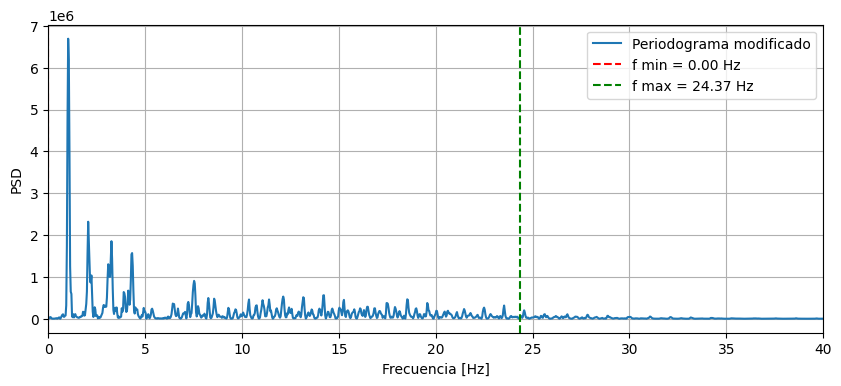

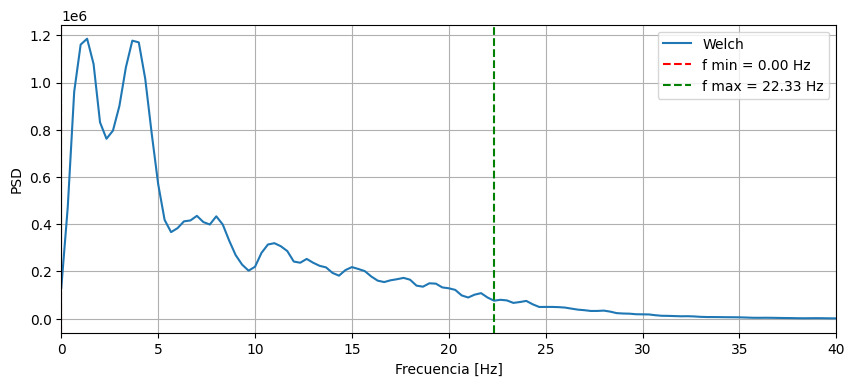

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
# Señal
fs_ecg = 1000
ecg_one_lead = np.load('ecg_sin_ruido.npy')

# PERIODOGRAMA MODIFICADO

f_perio, dsp_perio = sig.periodogram(
    ecg_one_lead,
    fs=fs_ecg,
    window='flattop',
    detrend='constant',
    scaling='density'
)


# Banda ocupada 95%

df_perio = f_perio[1] - f_perio[0]

energia_total_perio = np.sum(dsp_perio) * df_perio

energia_acum_perio = np.cumsum(dsp_perio) * df_perio
energia_acum_perio /= energia_total_perio

idx_min_perio = np.where(energia_acum_perio >= 0.0)[0][0]
idx_max_perio = np.where(energia_acum_perio >= 0.95)[0][0]

bw_min_perioa = f_perio[idx_min_perio]
bw_max_perioa = f_perio[idx_max_perio]


# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_perio, dsp_perio,
         label='Periodograma modificado')

plt.axvline(bw_min_perioa,color='r',
            linestyle='--',
            label=f'f min = {bw_min_perioa:.2f} Hz')

plt.axvline(bw_max_perioa,color='g',
            linestyle='--',
            label=f'f max = {bw_max_perioa:.2f} Hz')

plt.xlim(0,40)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')

plt.grid()
plt.legend()

plt.show()

# WELCH

f_welch, dsp_welch = sig.welch(
    ecg_one_lead,
    fs=fs_ecg,
    window='flattop',
    nperseg=len(ecg_one_lead)/10,
    detrend='constant',
    scaling='density'
)

# Banda ocupada 95%

df_welch = f_welch[1] - f_welch[0]

energia_total_welch = np.sum(dsp_welch) * df_welch

energia_acum_welch = np.cumsum(dsp_welch) * df_welch
energia_acum_welch /= energia_total_welch

idx_min_welch = np.where(energia_acum_welch >= 0.0)[0][0]
idx_max_welch = np.where(energia_acum_welch >= 0.95)[0][0]

bw_min_welcha = f_welch[idx_min_welch]
bw_max_welcha = f_welch[idx_max_welch]

# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_welch, dsp_welch,
         label='Welch')

plt.axvline(bw_min_welcha,color='r',
            linestyle='--',
            label=f'f min = {bw_min_welcha:.2f} Hz')

plt.axvline(bw_max_welcha,color='g',
            linestyle='--',
            label=f'f max = {bw_max_welcha:.2f} Hz')

plt.xlim(0,40)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')

plt.grid()
plt.legend()

plt.show()


a partir del estimador podemos una aproximacion de como se comporta la frecuencia de un electrocardiograma, a partir de ambos estimadores se llego que el ancho de banda de la señal es de aproximadamente de 0 a 30 Hz. este resultado lo podemos relacionar directamente con las frecuencias cardiacas, siendo que teoricamente las frecuencias de los ecg van de 0 a 100hz. 
si bien ambos estimadores parecen tener un ancho de banda parecido por no decir casi identico, su densisdad espectral de potencia son diferentes aunque cabe decir que sus envolventes son parecidas. la principal diferencia de esto es que el metodo de welchm, al poder variar la varianza a partir de la cantidad de promedios hace que haya menos ruido dentro del espectro,esto (como habiamos dicho en la introduccion) trae consigo que perdamos informacion por lo que si hacemos muchos promedios podriamos perder informacion. 

En este caso, analizando el silbido, el estimador de Welch llega a que el ancho de banda de la señal es de aproximadamente de 2680 a 6653 Hz, mientras que el periodograma modificado nos dice que el ancho de banda es de 2635 a 6667 Hz. Los valores son muy parecidos ya que el error relativo entre ellos es menor al 1,7%. Y esto se debe a que Welch promedia a lo cual hay menor vairanza, y con eso puede tomar un valor distinto del limite de la frecuenciad del ancho de banda

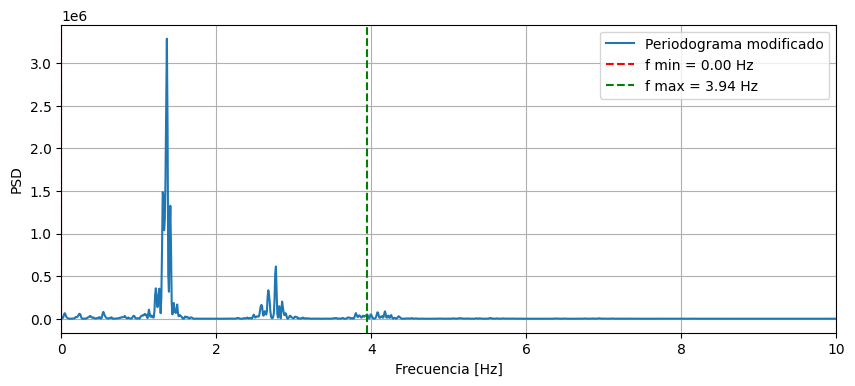

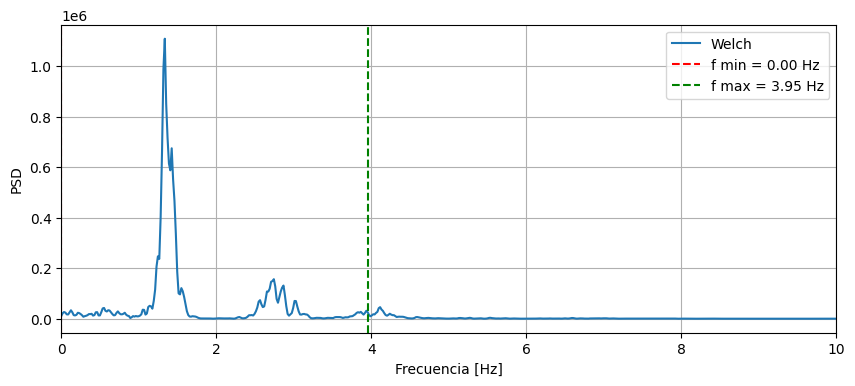

In [41]:
# Señal
fs_ppg = 400 # Hz

ppg = np.load('ppg_sin_ruido.npy')
# PERIODOGRAMA MODIFICADO

f_perio, dsp_perio = sig.periodogram(
    ppg,
    fs=fs_ppg,
    window='flattop',
    detrend='constant',
    scaling='density'
)



df_perio = f_perio[1] - f_perio[0]

energia_total_perio = np.sum(dsp_perio) * df_perio

energia_acum_perio = np.cumsum(dsp_perio) * df_perio
energia_acum_perio /= energia_total_perio

idx_min_perio = np.where(energia_acum_perio >= 0.0)[0][0]
idx_max_perio = np.where(energia_acum_perio >= 0.95)[0][0]

bw_min_periob = f_perio[idx_min_perio]
bw_max_periob = f_perio[idx_max_perio]


# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_perio, dsp_perio,
         label='Periodograma modificado')

plt.axvline(bw_min_periob,color='r',
            linestyle='--',
            label=f'f min = {bw_min_periob:.2f} Hz')

plt.axvline(bw_max_periob,color='g',
            linestyle='--',
            label=f'f max = {bw_max_periob:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.xlim(0,10)
plt.grid()
plt.legend()

plt.show()

# WELCH

f_welch, dsp_welch = sig.welch(
    ppg,
    fs=fs_ppg,
    window='flattop',
    nperseg=len(ppg)/2,
    detrend='constant',
    scaling='density'
)

# Banda ocupada 95%

df_welch = f_welch[1] - f_welch[0]

energia_total_welch = np.sum(dsp_welch) * df_welch

energia_acum_welch = np.cumsum(dsp_welch) * df_welch
energia_acum_welch /= energia_total_welch

idx_min_welch = np.where(energia_acum_welch >= 0.0)[0][0]
idx_max_welch = np.where(energia_acum_welch >= 0.95)[0][0]

bw_min_welchb = f_welch[idx_min_welch]
bw_max_welchb = f_welch[idx_max_welch]

# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_welch, dsp_welch,
         label='Welch')

plt.axvline(bw_min_welchb,color='r',
            linestyle='--',
            label=f'f min = {bw_min_welchb:.2f} Hz')

plt.axvline(bw_max_welchb,color='g',
            linestyle='--',
            label=f'f max = {bw_max_welchb:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.xlim(0,10)
plt.grid()
plt.legend()

plt.show()

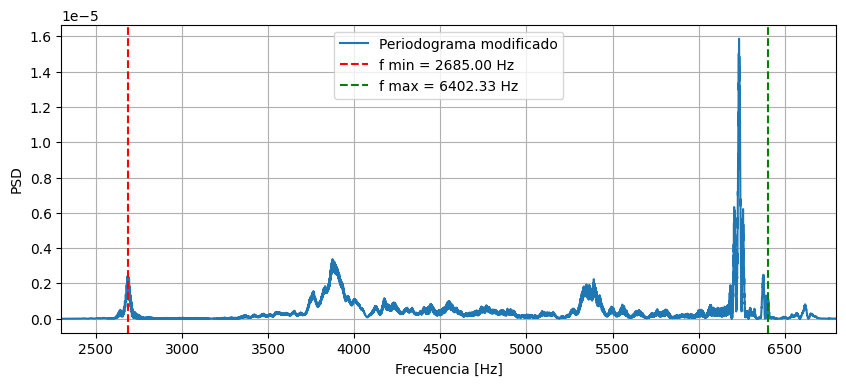

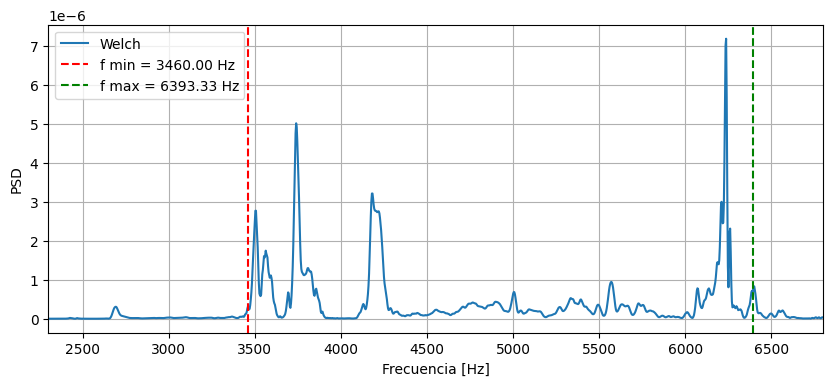

In [42]:


# Señal
fs_audio, wav_data = sio.wavfile.read('silbido.wav')
# PERIODOGRAMA MODIFICADO

f_perio, dsp_perio = sig.periodogram(
    wav_data,
    fs=fs_audio,
    window='flattop',
    detrend='constant',
    scaling='density'
)



df_perio = f_perio[1] - f_perio[0]

energia_total_perio = np.sum(dsp_perio) * df_perio

energia_acum_perio = np.cumsum(dsp_perio) * df_perio
energia_acum_perio /= energia_total_perio

idx_min_perio = np.where(energia_acum_perio >= 0.025)[0][0]
idx_max_perio = np.where(energia_acum_perio >= 0.975)[0][0]

bw_min_perioc = f_perio[idx_min_perio]
bw_max_perioc = f_perio[idx_max_perio]


# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_perio, dsp_perio,
         label='Periodograma modificado')

plt.axvline(bw_min_perioc,color='r',
            linestyle='--',
            label=f'f min = {bw_min_perioc:.2f} Hz')

plt.axvline(bw_max_perioc,color='g',
            linestyle='--',
            label=f'f max = {bw_max_perioc:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.grid()
plt.xlim(2300,6800)
plt.legend()
plt.show()

# WELCH

f_welch, dsp_welch = sig.welch(
    wav_data,
    fs=fs_audio,
    window='flattop',
    nperseg=len(wav_data)/10,
    detrend='constant',
    scaling='density'
)

# Banda ocupada 95%

df_welch = f_welch[1] - f_welch[0]

energia_total_welch = np.sum(dsp_welch) * df_welch

energia_acum_welch = np.cumsum(dsp_welch) * df_welch
energia_acum_welch /= energia_total_welch

idx_min_welch = np.where(energia_acum_welch >= 0.025)[0][0]
idx_max_welch = np.where(energia_acum_welch >= 0.975)[0][0]

bw_min_welchc = f_welch[idx_min_welch]
bw_max_welchc = f_welch[idx_max_welch]

# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_welch, dsp_welch,
         label='Welch')

plt.axvline(bw_min_welchc,color='r',
            linestyle='--',
            label=f'f min = {bw_min_welchc:.2f} Hz')

plt.axvline(bw_max_welchc,color='g',
            linestyle='--',
            label=f'f max = {bw_max_welchc:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.grid()
plt.legend()
plt.xlim(2300,6800)
plt.show()

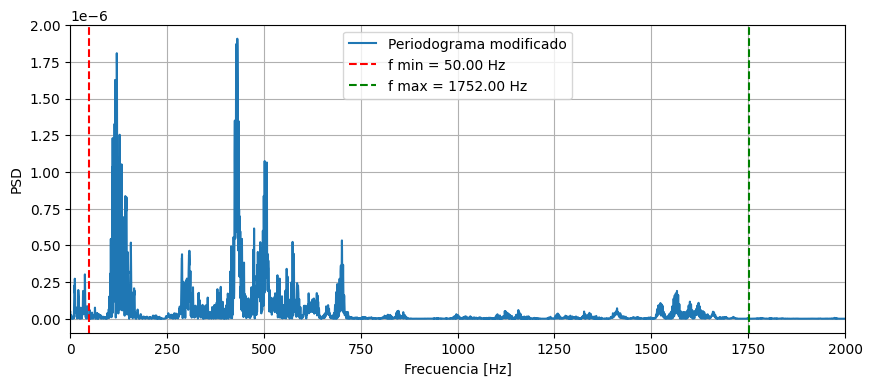

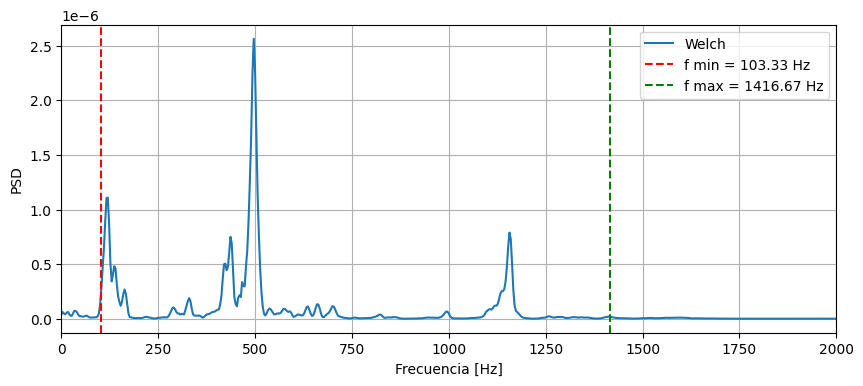

In [43]:
# Señal
fs_audio, wav_data =sio.wavfile.read('prueba psd.wav')
# PERIODOGRAMA MODIFICADO

f_perio, dsp_perio = sig.periodogram(
    wav_data,
    fs=fs_audio,
    window='flattop',
    detrend='constant',
    scaling='density'
)

df_perio = f_perio[1] - f_perio[0]

energia_total_perio = np.sum(dsp_perio) * df_perio

energia_acum_perio = np.cumsum(dsp_perio) * df_perio
energia_acum_perio /= energia_total_perio

idx_min_perio = np.where(energia_acum_perio >= 0.025)[0][0]
idx_max_perio = np.where(energia_acum_perio >= 0.975)[0][0]

bw_min_period = f_perio[idx_min_perio]
bw_max_period = f_perio[idx_max_perio]


# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_perio, dsp_perio,
         label='Periodograma modificado')

plt.axvline(bw_min_period,color='r',
            linestyle='--',
            label=f'f min = {bw_min_period:.2f} Hz')

plt.axvline(bw_max_period,color='g',
            linestyle='--',
            label=f'f max = {bw_max_period:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.grid()
plt.xlim(0,2000)
plt.legend()
plt.show()

# WELCH

f_welch, dsp_welch = sig.welch(
    wav_data,
    fs=fs_audio,
    window='flattop',
    nperseg=len(wav_data)/10,
    detrend='constant',
    scaling='density'
)

# Banda ocupada 95%

df_welch = f_welch[1] - f_welch[0]

energia_total_welch = np.sum(dsp_welch) * df_welch

energia_acum_welch = np.cumsum(dsp_welch) * df_welch
energia_acum_welch /= energia_total_welch

idx_min_welch = np.where(energia_acum_welch >= 0.025)[0][0]
idx_max_welch = np.where(energia_acum_welch >= 0.975)[0][0]

bw_min_welchd = f_welch[idx_min_welch]
bw_max_welchd= f_welch[idx_max_welch]

# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_welch, dsp_welch,
         label='Welch')

plt.axvline(bw_min_welchd,color='r',
            linestyle='--',
            label=f'f min = {bw_min_welchd:.2f} Hz')

plt.axvline(bw_max_welchd,color='g',
            linestyle='--',
            label=f'f max = {bw_max_welchd:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.grid()
plt.legend()
plt.xlim(0,2000)
plt.show()

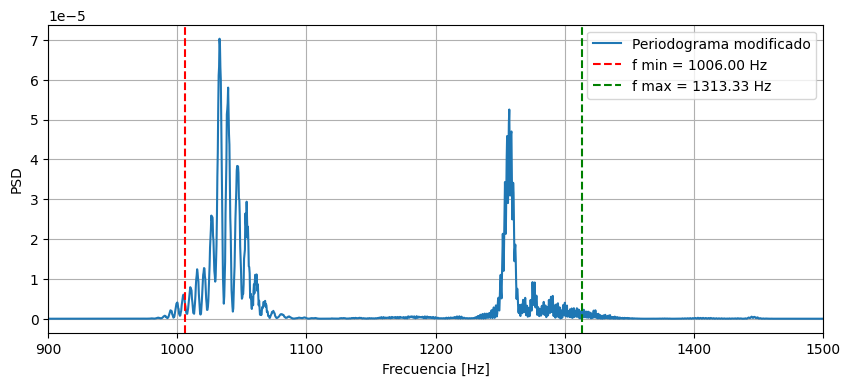

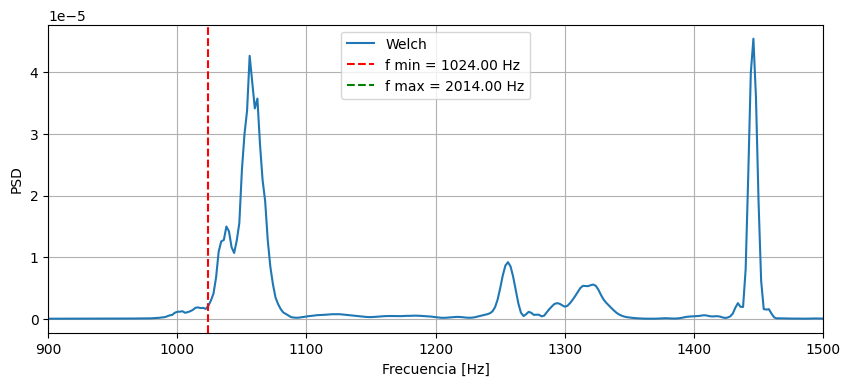

In [44]:
# Señal
fs_audio, wav_data =sio.wavfile.read('la cucaracha.wav')
# PERIODOGRAMA MODIFICADO

f_perio, dsp_perio = sig.periodogram(
    wav_data,
    fs=fs_audio,
    window='flattop',
    detrend='constant',
    scaling='density'
)

df_perio = f_perio[1] - f_perio[0]

energia_total_perio = np.sum(dsp_perio) * df_perio

energia_acum_perio = np.cumsum(dsp_perio) * df_perio
energia_acum_perio /= energia_total_perio

idx_min_perio = np.where(energia_acum_perio >= 0.025)[0][0]
idx_max_perio = np.where(energia_acum_perio >= 0.975)[0][0]

bw_min_perioe = f_perio[idx_min_perio]
bw_max_perioe = f_perio[idx_max_perio]


# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_perio, dsp_perio,
         label='Periodograma modificado')

plt.axvline(bw_min_perioe,color='r',
            linestyle='--',
            label=f'f min = {bw_min_perioe:.2f} Hz')

plt.axvline(bw_max_perioe,color='g',
            linestyle='--',
            label=f'f max = {bw_max_perioe:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.grid()

plt.xlim(900,1500)
plt.legend()
plt.show()

# WELCH

f_welch, dsp_welch = sig.welch(
    wav_data,
    fs=fs_audio,
    window='flattop',
    nperseg=len(wav_data)/6,
    detrend='constant',
    scaling='density'
)

# Banda ocupada 95%

df_welch = f_welch[1] - f_welch[0]

energia_total_welch = np.sum(dsp_welch) * df_welch

energia_acum_welch = np.cumsum(dsp_welch) * df_welch
energia_acum_welch /= energia_total_welch

idx_min_welch = np.where(energia_acum_welch >= 0.025)[0][0]
idx_max_welch = np.where(energia_acum_welch >= 0.975)[0][0]

bw_min_welche = f_welch[idx_min_welch]
bw_max_welche = f_welch[idx_max_welch]

# Gráfico

plt.figure(figsize=(10,4))

plt.plot(f_welch, dsp_welch,
         label='Welch')

plt.axvline(bw_min_welche,color='r',
            linestyle='--',
            label=f'f min = {bw_min_welche:.2f} Hz')

plt.axvline(bw_max_welche,color='g',
            linestyle='--',
            label=f'f max = {bw_max_welche:.2f} Hz')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.grid()
plt.xlim(900,1500)
plt.legend()
plt.show()

In [45]:
print(f'BW min Periodograma: {bw_min_perioa:.2f} Hz')
print(f'BW max Periodograma: {bw_max_perioa:.2f} Hz')

print(f'BW min Welch: {bw_min_welcha:.2f} Hz')
print(f'BW max Welch: {bw_max_welcha:.2f} Hz')

print(f'BW min Periodograma: {bw_min_periob:.2f} Hz')
print(f'BW max Periodograma: {bw_max_periob:.2f} Hz')

print(f'BW min Welch: {bw_min_welchb:.2f} Hz')
print(f'BW max Welch: {bw_max_welchb:.2f} Hz')

print(f'BW min Periodograma: {bw_min_perioc:.2f} Hz')
print(f'BW max Periodograma: {bw_max_perioc:.2f} Hz')

print(f'BW min Welch: {bw_min_welchc:.2f} Hz')
print(f'BW max Welch: {bw_max_welchc:.2f} Hz')

print(f'BW min Periodograma: {bw_min_period:.2f} Hz')
print(f'BW max Periodograma: {bw_max_period:.2f} Hz')

print(f'BW min Welch: {bw_min_welchd:.2f} Hz')
print(f'BW max Welch: {bw_max_welchd:.2f} Hz')

print(f'BW min Periodograma: {bw_min_perioe:.2f} Hz')
print(f'BW max Periodograma: {bw_max_perioe:.2f} Hz')

print(f'BW min Welch: {bw_min_welche:.2f} Hz')
print(f'BW max Welch: {bw_max_welche:.2f} Hz')

BW min Periodograma: 0.00 Hz
BW max Periodograma: 24.37 Hz
BW min Welch: 0.00 Hz
BW max Welch: 22.33 Hz
BW min Periodograma: 0.00 Hz
BW max Periodograma: 3.94 Hz
BW min Welch: 0.00 Hz
BW max Welch: 3.95 Hz
BW min Periodograma: 2685.00 Hz
BW max Periodograma: 6402.33 Hz
BW min Welch: 3460.00 Hz
BW max Welch: 6393.33 Hz
BW min Periodograma: 50.00 Hz
BW max Periodograma: 1752.00 Hz
BW min Welch: 103.33 Hz
BW max Welch: 1416.67 Hz
BW min Periodograma: 1006.00 Hz
BW max Periodograma: 1313.33 Hz
BW min Welch: 1024.00 Hz
BW max Welch: 2014.00 Hz


## Conclusiones

A partir de los resultados obtenidos puede observarse que tanto el periodograma modificado como el método de Welch permiten estimar correctamente el contenido frecuencial dominante de las señales analizadas. En ambos casos se utilizó una ventana FlatTop, priorizando una mejor estimación de amplitud espectral a costa de una menor resolución en frecuencia.

En general, el método de Welch produjo estimaciones más suaves y estables que el periodograma modificado, como consecuencia, disminuye significativamente la varianza del estimador y se obtiene una PSD menos ruidosa. Sin embargo, esta reducción de varianza implica una pérdida de resolución espectral, ya que cada bloque posee menor longitud temporal que la señal original.Por otro lado, el periodograma modificado conserva una mejor resolución frecuencial debido a que utiliza la totalidad de la señal para calcular la DFT. No obstante, presenta una mayor varianza, generando PSD más irregulares y sensibles al ruido.

En el caso del ECG, ambos métodos estimaron un ancho de banda cercano a 25 Hz, mientras que bibliográficamente suele considerarse que el contenido útil del ECG puede extenderse aproximadamente hasta 40 Hz. Este resultado sigue siendo razonable debido a que el criterio utilizado fue el de banda ocupada al 95% de energía. La mayor parte de la energía del ECG se concentra en bajas frecuencias, especialmente asociadas a las ondas P, QRS y T, mientras que las componentes superiores a 25–40 Hz poseen menor energía relativa. Por este motivo, el criterio energético utilizado descarta naturalmente parte de dichas componentes de alta frecuencia.

Para la señal PPG se obtuvo un ancho de banda muy reducido, cercano a 4 Hz, lo cual también resulta coherente físicamente. La pletismografía es una señal extremadamente lenta y periódica, cuya información principal está relacionada con la frecuencia cardíaca y sus armónicos de baja frecuencia, comportándose efectivamente como una señal pasabajos.

En los registros de audio se observó un comportamiento distinto. Tanto en “silbido” como en “la cucaracha” y “prueba PSD”, la energía se concentró en bandas alejadas de DC, mostrando un comportamiento equivalente al de señales pasabanda. Esto es esperable, ya que las componentes fundamentales y armónicos del habla y del silbido se encuentran en rangos medios de frecuencia y no concentrados alrededor de 0 Hz. También puede observarse que en algunos casos Welch produce bandas más estrechas que el periodograma modificado. Esto se debe nuevamente al promediado espectral, que suaviza componentes de menor energía y tiende a concentrar la estimación sobre las componentes dominantes de la señal.
